### データ入力

In [1]:
from src.tsplib_data import load_data

In [2]:
file_name = 'burma14.tsp'

In [3]:
data = load_data(file_name=file_name)
data

TSP(file_name='burma14', edge_weight_type='GEO', dimension=14, coordinate={1: [16.47, 96.1], 2: [16.47, 94.44], 3: [20.09, 92.54], 4: [22.39, 93.37], 5: [25.23, 97.24], 6: [22.0, 96.05], 7: [20.47, 97.02], 8: [17.2, 96.29], 9: [16.3, 97.38], 10: [14.05, 98.12], 11: [16.53, 97.38], 12: [21.52, 95.59], 13: [19.41, 97.13], 14: [20.09, 94.55]})

### 前処理

In [4]:
from src.pre_processing import PreProcessing

In [5]:
pre_processing = PreProcessing()

#### 地点間の距離マトリクスを取得

In [6]:
dist_matrix = pre_processing.get_dist_matrix(data)
dist_matrix

array([[1.000e+00, 1.530e+02, 5.100e+02, 7.060e+02, 9.660e+02, 5.810e+02,
        4.550e+02, 7.000e+01, 1.600e+02, 3.720e+02, 1.570e+02, 5.670e+02,
        3.420e+02, 3.980e+02],
       [1.530e+02, 1.000e+00, 4.220e+02, 6.640e+02, 9.970e+02, 5.980e+02,
        5.070e+02, 1.970e+02, 3.110e+02, 4.790e+02, 3.100e+02, 5.810e+02,
        4.170e+02, 3.760e+02],
       [5.100e+02, 4.220e+02, 1.000e+00, 2.890e+02, 7.440e+02, 3.900e+02,
        4.370e+02, 4.910e+02, 6.450e+02, 8.800e+02, 6.180e+02, 3.740e+02,
        4.550e+02, 2.110e+02],
       [7.060e+02, 6.640e+02, 2.890e+02, 1.000e+00, 4.910e+02, 2.650e+02,
        4.100e+02, 6.640e+02, 8.040e+02, 1.070e+03, 7.680e+02, 2.590e+02,
        4.990e+02, 3.100e+02],
       [9.660e+02, 9.970e+02, 7.440e+02, 4.910e+02, 1.000e+00, 4.000e+02,
        5.140e+02, 9.020e+02, 9.900e+02, 1.261e+03, 9.470e+02, 4.180e+02,
        6.350e+02, 6.360e+02],
       [5.810e+02, 5.980e+02, 3.900e+02, 2.650e+02, 4.000e+02, 1.000e+00,
        1.680e+02, 5.220e+02, 6

### 定式化・モデル生成機能

In [7]:
from src.model import TspModel

In [8]:
tsp_model = TspModel()

#### 数理モデル、重み、QUBO生成

In [9]:
model = tsp_model.get_model(data, dist_matrix)

In [10]:
feed_dict = tsp_model.get_feed(s1=1.0, p1=0.5, p2=0.5, p3=10.0)

In [11]:
qubo, offset = tsp_model.to_qubo(model=model, feed_dict=feed_dict)

### アニーリング

In [12]:
sampleset = tsp_model.annealing(sampler="neal",qubo=qubo, num_reads=1, num_sweeps=20000)

In [13]:
checks = tsp_model.check(model, sampleset, feed_dict)
checks

[{}]

In [14]:
sample = sampleset.record[0][0].reshape(data.dimension, data.dimension)
sample

array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0]], dtype=int8)

### 後処理

In [15]:
from src.post_proceesing import PostProcessing

In [16]:
post_proceesing = PostProcessing()

In [17]:
def display_actual_distance(data, id_sequence):
    """目的関数の実測値を表示

    Args:
        data (tsplib_data.TSP): TSPデータ
        id_sequence (list): アニーリングで採用された地点ID
    """
    between_two_point_dists = {}
    total_distance = 0.0
    for i in range(data.dimension):
        key = f"{id_sequence[i]} -> {id_sequence[i+1]}"
        dist = pre_processing.get_dist(data.edge_weight_type, data.coordinate[id_sequence[i]], data.coordinate[id_sequence[i+1]])
        between_two_point_dists[key] = dist
        total_distance += dist

    print("between_two_point_dists: ", between_two_point_dists)
    print("total_distance: " , total_distance)

#### 量子アニーリング結果の可視化

In [18]:
id_sequence = post_proceesing.get_result_city_id(data, sample)

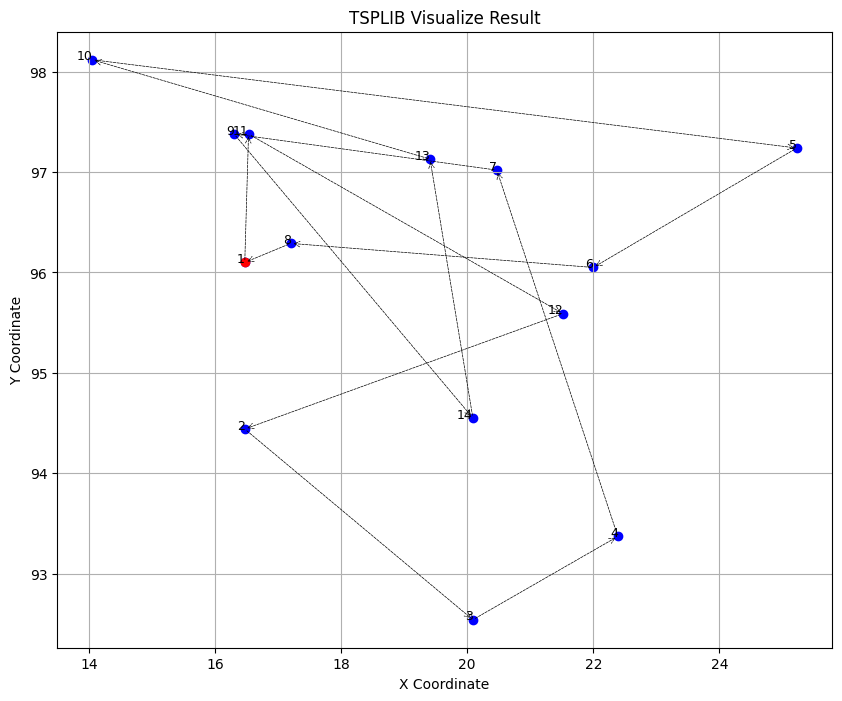

between_two_point_dists:  {'1 -> 11': 157, '11 -> 12': 582, '12 -> 2': 581, '2 -> 3': 422, '3 -> 4': 289, '4 -> 7': 410, '7 -> 9': 482, '9 -> 14': 498, '14 -> 13': 247, '13 -> 10': 633, '10 -> 5': 1261, '5 -> 6': 400, '6 -> 8': 522, '8 -> 1': 70}
total_distance:  6554.0


In [19]:
post_proceesing.plot_route(data, id_sequence)
display_actual_distance(data, id_sequence)

#### 補足: 正解データ(期待値)の可視化

In [20]:
# 正解データ
if data.file_name == 'burma14':
    id_sequence = [1,10,9,11,8,13,7,12,6,5,4,3,14,2,1]
elif data.file_name == 'eil51':
    id_sequence = [
        1, 22, 8, 26, 31, 28, 3, 36, 35, 20,
        2, 29, 21, 16, 50, 34, 30, 9, 49, 10,
        39, 33, 45, 15, 44, 42, 40, 19, 41, 13,
        25, 14, 24, 43, 7, 23, 48, 6, 27, 51,
        46, 12, 47, 18, 4, 17, 37, 5, 38, 11, 32, 1
    ]

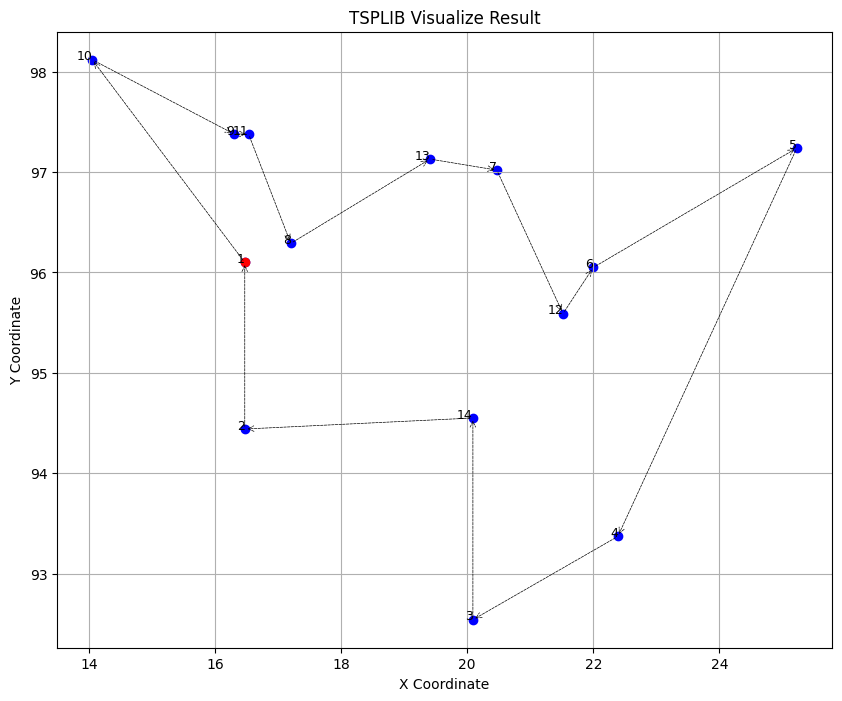

between_two_point_dists:  {'1 -> 10': 372, '10 -> 9': 276, '9 -> 11': 43, '11 -> 8': 133, '8 -> 13': 273, '13 -> 7': 124, '7 -> 12': 163, '12 -> 6': 19, '6 -> 5': 400, '5 -> 4': 491, '4 -> 3': 289, '3 -> 14': 211, '14 -> 2': 376, '2 -> 1': 153}
total_distance:  3323.0


In [21]:
post_proceesing.plot_route(data, id_sequence)
display_actual_distance(data, id_sequence)